# Julia Machine Learning demo

## Image classification with the MNIST dataset

Before running this notebook, start Julia in the project folder with `julia --project=.` and add the required packages in Pkg mode with:

```julia
add MLDatasets Colors Plots Lux Optimisers Zygote MLUtils OneHotArrays Random
```

MNIST is a classic Machine Learning dataset that is used for training and testing image classifiers. It contains 70'000 labeled 28-by-28 pixel images of handwritten numbers from 0 to 9. In image classification, we aim to predict the contents of the image using a neural network. In this demo, we will train a network that is able to output a digital number from an image of a handwritten number.

### Data retrieval

First, import MLDatasets, which we can use to get the MNIST dataset

In [3]:
using MLDatasets
# Fetch training dataset
trainset = MNIST(:train)
# Print dataset info
trainset

dataset MNIST:
  metadata  =>    Dict{String, Any} with 3 entries
  split     =>    :train
  features  =>    28×28×60000 Array{Float32, 3}
  targets   =>    60000-element Vector{Int64}

In [4]:
# Fetch testing dataset
testset = MNIST(:test)
# Print dataset info
testset

dataset MNIST:
  metadata  =>    Dict{String, Any} with 3 entries
  split     =>    :test
  features  =>    28×28×10000 Array{Float32, 3}
  targets   =>    10000-element Vector{Int64}

### Data visualization

The trainset and testset are now Julia namedtuples, and we can see that the features field contains the images and targets contain the labels. Lets plot three random training set samples and their labels.

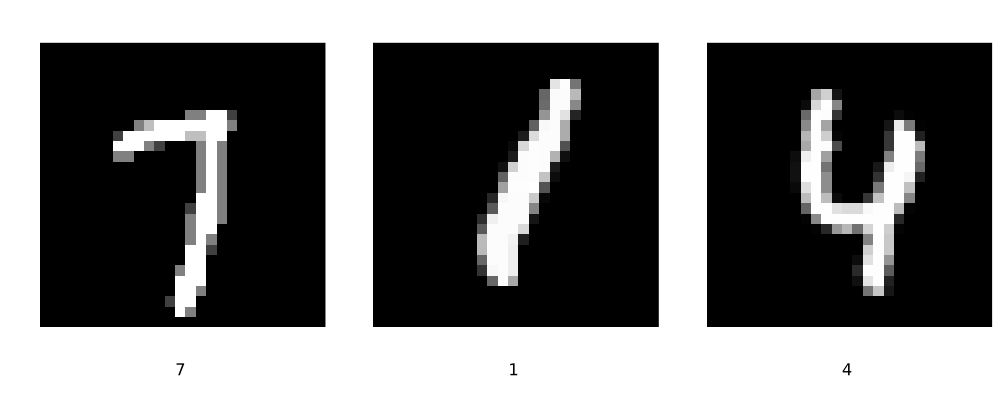

In [5]:
# Use COlors.jl to convert float numbers to gray scale
using Colors
using Plots
# For controlling the plot margins
using Plots.Measures: mm
using Random

# Extract training and testing datasets
x_train = trainset.features
y_train = trainset.targets

x_test = testset.features
y_test = testset.targets

# Get 3 random indecies from y_train
a_idx = rand(1:length(y_train))
b_idx = rand(1:length(y_train))
c_idx = rand(1:length(y_train))

# Get labels of the random indecies
a_label = y_train[a_idx]
b_label = y_train[b_idx]
c_label = y_train[c_idx]

# Get images, transpose them and turn to grayscale
a_img = Gray.(transpose(x_train[:, :, a_idx]))
b_img = Gray.(transpose(x_train[:, :, b_idx]))
c_img = Gray.(transpose(x_train[:, :, c_idx]))

# Plot each image and label seperately
p1 = plot(a_img, xlim=(0, 28), ylim=(0, 28), xlabel=a_label)
p2 = plot(b_img, xlim=(0, 28), ylim=(0, 28), xlabel=b_label)
p3 = plot(c_img, xlim=(0, 28), ylim=(0, 28), xlabel=c_label)

# Combine plots to side-by-side layout. Hide axis and grid and change margin 0 mm
plot(p1, p2, p3, layout=(1,3), size=(1000, 400), axis=false, grid=false, margin=0mm)

Before we define the neural network, let us explore convolution, pooling and flatten layers, as they are essential in image recognition.

Note: the local demo figure and gif used below have been moved to the data directory for this notebook.

## Convolutional layers

Image convolution applies a filter over the input data, which in our case are two dimensional arrays. In the following image we see a 3-by-3 convolution filter (also called the kernel) applied to a region in a two dimensional array. The array is padded with zeros, so that the filter can be applied to the outermost values. The filter is applied with an element-wise matrix multiplication and by summation of the resulting elements.

<div align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/b/bd/Convolutional_neural_network%2C_convolution_worked_example.png">
</div>
<p style="text-align: center;">Daniel Voigt Godoy, CC BY 4.0, via Wikimedia Commons</p>

The whole convolution process for an image can be seen in the following gif.

<div align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/1/19/2D_Convolution_Animation.gif">
</div>
<p style="text-align: center;">Michael Plotke, CC BY-SA 3.0, via Wikimedia Commons</p>

In a neural network convolutional layer, the convolution filter is not predefined but learned. The filter elements are weights that are first set to random values and are updated via backpropagation during network training.

### Stride

If we want to reduce the size of the output array, we can increase the filter stride. The stride determines how many elements the filter moves at a time. In the following gif, no zero-padding is used and the filter has stride 3 in the vertical and horizontal directions, reducing our output to a 2-by-2 array.

![](data/stride.gif)

### Channels

A convolutional layer input can have multiple channels. For example, RGB images have three channels, one for each color. In that case, we can use the same or different filters separately on each channel and get an output with three channels or combine the output channels to one channel. We could also increase the number of channels with same or different filters. In the following image, separate filters are used on the different channels and the channel outputs are summed to get a single channel output. 

<div align="center">
  <img src="https://raw.githubusercontent.com/dvgodoy/dl-visuals/main/Convolutions/3channel1.png">
</div>
<p style="text-align: center;">Daniel Voigt Godoy, CC BY 4.0, via https://dvgodoy.github.io/dl-visuals/Convolutions/</p>

## Pooling layers

Pooling layers downsample arrays by dividing them into regions and calculating the output value of the region with some pooling operation. We will be using max pooling, which outputs the maximum value in the region. The following image uses Max pooling with 2-by-2 regions.

<div align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/Max_pooling.png">
</div>
<p style="text-align: center;">Aphex34, CC BY-SA 4.0, via Wikimedia Commons</p>

## Flatten layers

And finally, flatten layers transform arrays to vectors. In image classification with neural networks, this is usually done after all of the convolutional layers, since most other layers, like dense layers, work with vectors and not arrays.

![](data/flatten.png)

Flatten can be used on arrays with multiple channels to get multiple vectors, which can be concatenated to a single vector.

## Visual, hands on example

In the following web application by Adam Harley, we can interactively visualize a convolutional neural network that classifies digits.

[https://adamharley.com/nn_vis/cnn/3d.html](https://adamharley.com/nn_vis/cnn/3d.html)

## Defining the network

Now we are ready to define the neural network with Lux.jl. The network will have the following layer structure:

1. Convolution
    - Filter = 5-by-5
    - Stride = 1
    - Upscales channels from 1 to 6
    - Relu activation
2. Max pooling
    - Regions = 2-by-2
3. Convolution
    - Filter = 5-by-5
    - Stride = 1
    - Upscales channels from 6 to 16
    - Relu activation
4. Max pooling
    - Regions = 2-by-2
5. Flatten layer
6. Dense layer
    - Input length = 256
    - Output length = 128
    - Relu activation
7. Dense layer
    - Input length = 128
    - Output length = 84
    - Relu activation
8. Dense layer
    - Input length = 84
    - Output length = 10
    - No activation

In [6]:
using Lux
using Optimisers
using Zygote

# Use Mersenne Twister random number generation
rng = MersenneTwister()
# Set learning rate
lr = 3.0f-4
# Define ADAM optimiser
opt = Adam(lr)
# Define the Neural Network
model = Chain(
    Conv((5, 5), 1 => 6, relu),
    MaxPool((2, 2)),
    Conv((5, 5), 6 => 16, relu),
    MaxPool((2, 2)),
    FlattenLayer(),
    Dense(256 => 128, relu),
    Dense(128 => 84, relu),
    Dense(84 => 10)
)
# Set up parameters and states for the Neural Network
ps, st = Lux.setup(rng, model)
# Initialize the training state object
tstate = Training.TrainState(model, ps, st, opt)

TrainState(
    Chain(
        layer_1 = Conv((5, 5), 1 => 6, relu),     # 156 parameters
        layer_2 = MaxPool((2, 2)),
        layer_3 = Conv((5, 5), 6 => 16, relu),    # 2_416 parameters
        layer_4 = MaxPool((2, 2)),
        layer_5 = FlattenLayer{Nothing}(nothing),
        layer_6 = Dense(256 => 128, relu),        # 32_896 parameters
        layer_7 = Dense(128 => 84, relu),         # 10_836 parameters
        layer_8 = Dense(84 => 10),                # 850 parameters
    ),
    number of parameters: 47154
    number of states: 0
    optimizer: Adam(eta=0.0003, beta=(0.9, 0.999), epsilon=1.0e-8)
    step: 0
)


## One-hot-encoding

The one-hot-encoding method turns our 0-9 representation of the output to a vector with length 10, where each element corresponds to a digit. The element values quantify the certainty our model has for that digit being the correct classification, with higher values indicating higher certainty. Hence our model output could be

```
Output = [-2.27, -5.0, -4.5, -3.0, 13.7, -3.0, -0.8, -0.6, 0.5, 6.1]
 Digit =      0     1     2     3     4     5     6     7    8    9
```

Meaning that the model is most certain that the hand drawn digit in the image is a 4. This encoding method is the reason our model output size is 10, and not 1.

OneHotArrays.jl package is used for encoding the true labels to batches of one-hot-vectors and to decode the model output one-hot-vectors to digits. 

## Reshaping the input data

Next we need to reshape the data and create dataloaders. Dataloaders come from the MLUtils.jl package and are used to serve batches of data. which makes training faster than performing backpropagation on each training iteration. The images are reshaped from [28, 28, 60000] to [28, 28, 1, 60000], since convolution layers expect input in the form [H, W, C, B], where

- H = Heigth
- W = Width
- C = Channels
- B = Batch

Our input data has just one channel, as we are working with grayscale images, but we still need to represent the data in this form.

In [7]:
using MLUtils
using OneHotArrays

# Number of train and test samples
N_train = length(y_train)
N_test = length(y_test)

# Define batch size
batch_size = 128

# Reshape x from [28, 28, 60000] to [28, 28, 1, 60000]
x_train = Float32.(reshape(x_train, size(x_train, 1), size(x_train, 2), 1, N_train))
# Make y into one hot vector
y_train = onehotbatch(y_train, 0:9)

# Create the dataloader. Define batch size and shuffle data.
train_loader = DataLoader((x_train, y_train); batchsize=batch_size, shuffle=true, partial=false)

# Do the same for test data
x_test = Float32.(reshape(x_test, size(x_test, 1), size(x_test, 2), 1, N_test))
y_test = onehotbatch(y_test, 0:9)
test_loader = DataLoader((x_test, y_test); batchsize=batch_size, shuffle=false, partial=false)

78-element DataLoader(::Tuple{Array{Float32, 4}, OneHotMatrix{UInt32, Vector{UInt32}}}, batchsize=128, partial=false)
  with first element:
  (28×28×1×128 Array{Float32, 4}, 10×128 OneHotMatrix(::Vector{UInt32}) with eltype Bool,)

## Training the network

Now we can train our network. First we define the number of epochs we want to train, then we go through the whole dataset in each epoch, batch by batch. We use the cross entropy loss as it works well in multi-class classification, and we define logits=Val(true) as our model outputs are not normalized and do not represent probabilities.

In [8]:
# Define number of epochs
epochs = 10
# For each epoch
for epoch in 1:epochs
    # Track average loss 
    avg_loss = 0
    num_batches = 0
    # For each training batch
    for (x, y) in train_loader
        # Train the model with AutoZygote backpropagation, CrossEntropy loss, x input, y true labels and tstate object
        _, batch_loss, _, tstate = Lux.Training.single_train_step!(Lux.AutoZygote(), CrossEntropyLoss(; logits=Val(true)), (x, y), tstate)
        # Increment variables
        avg_loss += batch_loss
        num_batches += 1
    end
    avg_loss /= num_batches
    println("Epoch $(epoch)/$(epochs), loss = $(avg_loss)")
end

Epoch 1/10, loss = 0.6238458
Epoch 2/10, loss = 0.18798812
Epoch 3/10, loss = 0.12827499
Epoch 4/10, loss = 0.09856217
Epoch 5/10, loss = 0.08311498
Epoch 6/10, loss = 0.07063329
Epoch 7/10, loss = 0.060443114
Epoch 8/10, loss = 0.05436523
Epoch 9/10, loss = 0.048267066
Epoch 10/10, loss = 0.041842602


## Testing the network

Now we can test the network by giving each test batch to the network and calculating the accuracy based on the number of correct and incorrect predictions.

In [9]:
# Initialize variables
correct = 0
total = 0
# Loop over each test batch
for (x, y) in test_loader
    # Get true values
    y_true = onecold(Array(y), 0:9)
    # Infer
    y_pred = onecold(Array(first(tstate.model(x, tstate.parameters, Lux.testmode(tstate.states)))), 0:9)
    # Add number of correct predictions to sum
    correct += sum(y_true .== y_pred)
    total += length(y_true)
end

# Calculate accuracy
accuracy = correct / total
print(accuracy)

0.9824719551282052

## Inference

We can infer the model to display random test set images and show the predicted label.

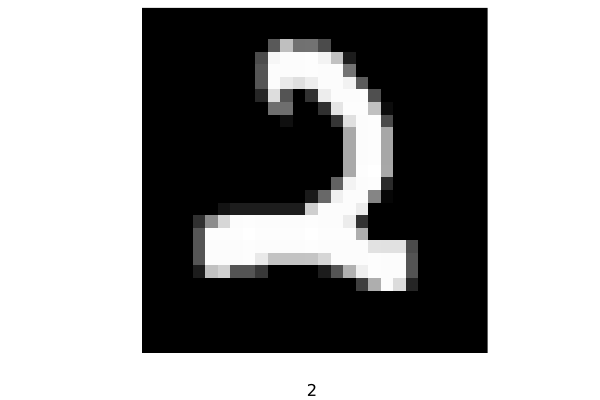

In [10]:
# Fetch random test set sample
idx = rand(1:10000)
x_sample = x_test[:, :, 1, idx]
x_sample_reshaped = reshape(x_sample, 28, 28, 1, 1)
y_sample = y_test[idx]

# Infer by
# 1. passing the data, parameters and states to the tstate.model
model_output = tstate.model(x_sample_reshaped, tstate.parameters, Lux.testmode(tstate.states))
# 2. getting the first value in the output, i.e. the prediction
prediction = first(model_output)
# 3. transforming the value to an array
pred_array = Array(prediction)
# 4. decoding the one-hot-encoding
decoded = onecold(pred_array, 0:9)
# 5. fetching the digit prediction from the single-element array
y_pred = decoded[1]

# Same as a one-liner
#y_pred = onecold(Array(first(tstate.model(x_sample_reshaped, tstate.parameters, Lux.testmode(tstate.states)))), 0:9)[1]

# Plot
plot(Gray.(transpose(x_sample)), xlim=(0, 28), ylim=(0, 28), xlabel=y_pred, axis=false, grid=false, margin=0mm)